In [1]:
from tests.test_vinecop import sim_vcp_from_bcp
import torchvinecopulib as tvc

V_mvcp = sim_vcp_from_bcp(
    bcp_tvc=tvc.bicop.Clayton,
)

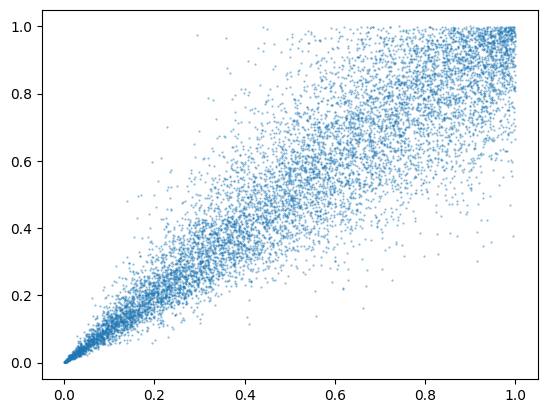

In [37]:
import matplotlib.pyplot as plt
plt.scatter(*V_mvcp[:,:2].T, s=.3, alpha=.5)

In [4]:
mdl_vcp = tvc.vinecop.vcp_from_obs(V_mvcp)

In [6]:
print(mdl_vcp)

{'num_dim': 6,
 'num_obs': 10_000,
 'num_par': 5,
 'negloglik': -33075.5102,
 'aic': -66141.0205,
 'bic': -66104.9688,
 'matrix': '[[ 2  4  5  0  1  3]'
           ' [-1  3  4  5  0  1]'
           ' [-1 -1  1  4  5  0]'
           ' [-1 -1 -1  0  4  5]'
           ' [-1 -1 -1 -1  4  5]'
           ' [-1 -1 -1 -1 -1  5]]'}


In [27]:
self = mdl_vcp
lv = 1
lst_arrow = []
lst_obs = []
for v_l, v_r, s_and in self.dct_tree[lv]:
    lst_obs.append((v_l, s_and))
    lst_obs.append((v_r, s_and))
    lst_arrow.append(((v_l, s_and), (v_l, v_r, s_and)))
    lst_arrow.append(((v_r, s_and), (v_l, v_r, s_and)))
    if lv >0:
        tpl = self._loc_bcp(v_down=v_l, s_down=s_and)
        lst_arrow.append(((tpl[0], tpl[1], tpl[2]), (v_l,  s_and)))
        tpl = self._loc_bcp(v_down=v_r, s_down=s_and)
        lst_arrow.append(((tpl[0], tpl[1], tpl[2]), (v_r,  s_and)))
    # [((v_l, s_and), (v_r,s_and)) for v_l, v_r, s_and in self.dct_tree[lv]]

我们现在能直接调用的是dct_tree接口，也就是edge。而obs就得使用手动或函数进行推导了。
_loc_bcp是给定下层，能够找到上层的函数，因此比较方便用于画obs到edge的箭头。

In [39]:
#self.draw(lv=4, is_mst=False)
print(lst_obs)
print(lst_arrow)
print(self.dct_tree[lv])

[(0, frozenset({1})), (3, frozenset({1})), (1, frozenset({0})), (5, frozenset({0})), (0, frozenset({5})), (4, frozenset({5})), (1, frozenset({3})), (2, frozenset({3}))]
[((0, frozenset({1})), (0, 3, frozenset({1}))), ((3, frozenset({1})), (0, 3, frozenset({1}))), ((0, 1, frozenset()), (0, frozenset({1}))), ((1, 3, frozenset()), (3, frozenset({1}))), ((1, frozenset({0})), (1, 5, frozenset({0}))), ((5, frozenset({0})), (1, 5, frozenset({0}))), ((0, 1, frozenset()), (1, frozenset({0}))), ((0, 5, frozenset()), (5, frozenset({0}))), ((0, frozenset({5})), (0, 4, frozenset({5}))), ((4, frozenset({5})), (0, 4, frozenset({5}))), ((0, 5, frozenset()), (0, frozenset({5}))), ((4, 5, frozenset()), (4, frozenset({5}))), ((1, frozenset({3})), (1, 2, frozenset({3}))), ((2, frozenset({3})), (1, 2, frozenset({3}))), ((1, 3, frozenset()), (1, frozenset({3}))), ((2, 3, frozenset()), (2, frozenset({3})))]
{(0, 3, frozenset({1})): 0.011974357435743573, (1, 5, frozenset({0})): 0.006281988198819881, (0, 4, fr

In [31]:
self.matrix

array([[ 2,  4,  5,  0,  1,  3],
       [-1,  3,  4,  5,  0,  1],
       [-1, -1,  1,  4,  5,  0],
       [-1, -1, -1,  0,  4,  5],
       [-1, -1, -1, -1,  4,  5],
       [-1, -1, -1, -1, -1,  5]])

In [35]:
lst_diag = self.diag
lst_diag = [(v, frozenset(lst_diag[(idx + 1) :])) for idx, v in enumerate(lst_diag)][
    ::-1
]
lst_diag

[(5, frozenset()),
 (4, frozenset({5})),
 (0, frozenset({4, 5})),
 (1, frozenset({0, 4, 5})),
 (3, frozenset({0, 1, 4, 5})),
 (2, frozenset({0, 1, 3, 4, 5}))]

diag函数能够把关键节点标出来，每一层都有一个最终留下来的关键节点，原则上需要从下向上画这些节点的箭头。但是暂时也不用这么搞，把这些关键节点用不同颜色标注即可。
做一个检定，如果数在这些里面则用另一种颜色，否则用通用色。

关于格式修改的prompt：
现在我需要你对代码实行这样的修改：
1. 对于每一层的dct_tree[lv]，里面的每一个元素都是由包含两个顶点和一个状态的元组组成，也即(v_l, v_r, s_and)。现在我需要将这个元组转化为字符串，要求如下：前面两个顶点的内容直接转化为字符串，用逗号","分隔。第三项状态是一个frozenset，你需要把frozenset里面的字符串提取出来。前两项和第三项之间要用分号";"分隔。如果frozenset为空，则没有第三项，也不再需要分号。也就是说，你最终应该得到一个类似于“1,2"或”1,2;3,5"这样的字符串。遍历这一层的所有元素，都将其转换成这样的字符串，然后将这些字符串放到同一个列表中lst_tree[lv]。
2. 对于每一层的lst_ob，你要用for v_l, v_r, s_and in self.dct_tree[lv]:的方法遍历dct_tree[lv]中的每一组元素，然后分别记录(v_l, s_and)和(v_r, s_and)，也要用下面的要求转换成字符串：前面一项直接转换成字符串，然后中间加上“|"隔线进行分隔，然后后面要放上frozenset里面提取出的字符串,形如"1|2,3"。如果frozenset为空，则没有后面的项，也不需要再加“|"隔线，此时相当于这个字符串当中只有一个数，如"1"。遍历这一层的所有元素，都将其转换成这样的字符串，然后将这些字符串放到一个列表lst_ob[lv]中。
3. 对于每一层的lst_arrow，你可以用：
    lst_arrow.append(((v_l, s_and), (v_l, v_r, s_and)))
    lst_arrow.append(((v_r, s_and), (v_l, v_r, s_and)))
    if lv >0:
        tpl = self._loc_bcp(v_down=v_l, s_down=s_and)
        lst_arrow.append(((tpl[0], tpl[1], tpl[2]), (v_l,  s_and)))
        tpl = self._loc_bcp(v_down=v_r, s_down=s_and)
        lst_arrow.append(((tpl[0], tpl[1], tpl[2]), (v_r,  s_and)))
这样的方法获得，但是每个元组里面现在是由两个元组构成，这不行，你需要重复1/2中的步骤，将每个元组中的两个元素都换成对应的两个字符串，比如（"1|2,3","1,4;2,3”）。然后再把这些元组转换成列表，都放在一个统一的列表lst_arrow[lv]中。
4. 在lv从小到大遍历完每一层后，你要将每一层的lst_tree[lv]列表按顺序打包进一个大列表tree_list中（注意，tree_list中每一个元素都是一个列表），然后将每一层的lst_ob[lv]列表按顺序打包进一个大列表obs_list中（注意，obs_list中每一个元素都是一个列表）。
然后将每一层的lst_arrow[lv]中的每一个包含2个字符串的列表，都统一放进arrow_list里面（注意和前面不同，arrow_list里的列表都是含有2个字符串的小列表，不是直接把lst_arrow[lv]的大列表打包扔进去）。
5. 最后用：lst_diag = self.diag
lst_diag = [(v, frozenset(lst_diag[(idx + 1) :])) for idx, v in enumerate(lst_diag)][
    ::-1
]
lst_diag
的方法生成一个lst_diag列表，里面的元素都是(5, frozenset())这样的格式，你还是把里面的每个元组都改写成字符串，如“5”，要求和上面改写dct_tree一样，要用“|”竖线分隔，最终得到一个含有若干个字符串的列表，命名为special_nodes。
6. 最终我们需要获得obs_list, tree_list, arrow_list, special_nodes四个列表，其中前三个列表中每个列表里面的元素都是列表，而special_nodes里面的元素是字符串。

In [48]:
'''
def process_tree(self):
    # 初始化列表
    lst_tree = [None] * len(self.dct_tree)
    lst_ob = [None] * len(self.dct_tree)
    lst_arrow = [None] * len(self.dct_tree)
    tree_list = []
    obs_list = []
    arrow_list = []

    # 遍历每一层
    for lv in range(len(self.dct_tree)):
        lst_tree[lv] = []
        lst_ob[lv] = []
        lst_arrow[lv] = []
        # 遍历每一层的每一个元素
        for v_l, v_r, s_and in self.dct_tree[lv]:
            # 转换元素为字符串
            s_and_str = ','.join(str(item) for item in s_and) if s_and else ''
            lst_tree[lv].append(f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else ''))
            # 记录观察点
            lst_ob[lv].append(f"{v_l}" + (f"|{s_and_str}" if s_and_str else ''))
            lst_ob[lv].append(f"{v_r}" + (f"|{s_and_str}" if s_and_str else ''))
            # 记录箭头
            lst_arrow[lv].append((f"{v_l}" + (f"|{s_and_str}" if s_and_str else ''), f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else '')))
            lst_arrow[lv].append((f"{v_r}" + (f"|{s_and_str}" if s_and_str else ''), f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else '')))
        if lv > 0:
            tpl = self._loc_bcp(v_down=v_l, s_down=s_and)
            tpl1_str = ','.join(str(item) for item in tpl[1]) if isinstance(tpl[1], Iterable) else str(tpl[1])
            lst_arrow[lv].append((f"{tpl[0]}|{tpl1_str},{tpl[2]}", f"{v_l}" + (f"|{s_and_str}" if s_and_str else '')))
            tpl = self._loc_bcp(v_down=v_r, s_down=s_and)
            tpl1_str = ','.join(str(item) for item in tpl[1]) if isinstance(tpl[1], Iterable) else str(tpl[1])
            lst_arrow[lv].append((f"{tpl[0]}|{tpl1_str},{tpl[2]}", f"{v_r}" + (f"|{s_and_str}" if s_and_str else '')))
        # 将每一层的列表打包进大列表
        tree_list.append(lst_tree[lv])
        obs_list.append(lst_ob[lv])
        arrow_list.extend(lst_arrow[lv])  # 注意这里是extend，不是append

    # 生成special_nodes列表
    lst_diag = self.diag
    lst_diag = [(v, frozenset(lst_diag[(idx + 1) :])) for idx, v in enumerate(lst_diag)][::-1]
    special_nodes = [f"{v}" + (f"|{','.join(str(item) for item in s)}" if s else '') for v, s in lst_diag]
    # 返回四个列表
    return obs_list, tree_list, arrow_list, special_nodes
'''

3.9更新：下面是修改后的process_tree函数。还需再优化，重点是生成箭头的问题。

In [58]:
def process_tree(self):
    from collections.abc import Iterable
    # 初始化列表
    lst_tree = [None] * len(self.dct_tree)
    lst_ob = [None] * len(self.dct_tree)
    lst_arrow = [None] * len(self.dct_tree)
    tree_list = []
    obs_list = []
    arrow_list = []

    # 遍历每一层
    for lv in range(len(self.dct_tree)):
        lst_tree[lv] = []
        lst_ob[lv] = []
        lst_arrow[lv] = []
        # 遍历每一层的每一个元素
        for v_l, v_r, s_and in self.dct_tree[lv]:
            # 转换元素为字符串
            s_and_str = ','.join(str(item) for item in s_and) if s_and else ''
            lst_tree[lv].append(f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else ''))
            # 记录观察点
            lst_ob[lv].append(f"{v_l}" + (f"|{s_and_str}" if s_and_str else ''))
            lst_ob[lv].append(f"{v_r}" + (f"|{s_and_str}" if s_and_str else ''))
            # 记录箭头
            lst_arrow[lv].append((f"{v_l}" + (f"|{s_and_str}" if s_and_str else ''), f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else '')))
            lst_arrow[lv].append((f"{v_r}" + (f"|{s_and_str}" if s_and_str else ''), f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else '')))
        if lv > 0:
            tpl = self._loc_bcp(v_down=v_l, s_down=s_and)
            tpl1_str = ','.join(str(item) for item in tpl[1]) if isinstance(tpl[1], Iterable) and tpl[1] else ''  # 添加条件判断
            lst_arrow[lv].append((f"{tpl[0]}" + (f"|{tpl1_str},{tpl[2]}" if tpl1_str else ''), f"{v_l}" + (f"|{s_and_str}" if s_and_str else '')))
            tpl = self._loc_bcp(v_down=v_r, s_down=s_and)
            tpl1_str = ','.join(str(item) for item in tpl[1]) if isinstance(tpl[1], Iterable) and tpl[1] else ''  # 添加条件判断
            lst_arrow[lv].append((f"{tpl[0]}" + (f"|{tpl1_str},{tpl[2]}" if tpl1_str else ''), f"{v_r}" + (f"|{s_and_str}" if s_and_str else '')))
        # 将每一层的列表打包进大列表
        tree_list.append(sorted(list(set(lst_tree[lv]))))  # 使用集合去重并排序
        obs_list.append(sorted(list(set(lst_ob[lv]))))  # 使用集合去重并排序
        arrow_list.extend(lst_arrow[lv])  # 注意这里是extend，不是append

    # 在生成arrow_list后，将整个列表转换为集合来去除重复元素，然后再使用sorted函数进行排序
    arrow_list = sorted(list(set(arrow_list)))

    # 生成special_nodes列表
    lst_diag = self.diag
    lst_diag = [(v, frozenset(lst_diag[(idx + 1) :])) for idx, v in enumerate(lst_diag)][::-1]
    special_nodes = [f"{v}" + (f"|{','.join(str(item) for item in s)}" if s else '') for v, s in lst_diag]
    # 返回四个列表
    return obs_list, tree_list, arrow_list, special_nodes

In [59]:
self = mdl_vcp
obs_list, tree_list, arrow_list, special_nodes = process_tree(self)
print(obs_list)
print(tree_list)
print(arrow_list)
print(special_nodes)

[['0', '1', '2', '3', '4', '5'], ['0|1', '0|5', '1|0', '1|3', '2|3', '3|1', '4|5', '5|0'], ['0|1,3', '1|0,5', '2|1,3', '3|0,1', '4|0,5', '5|0,1'], ['2|0,1,3', '3|0,1,5', '4|0,1,5', '5|0,1,3'], ['2|0,1,3,5', '4|0,1,3,5']]
[['0,1', '0,5', '1,3', '2,3', '4,5'], ['0,3;1', '0,4;5', '1,2;3', '1,5;0'], ['0,2;1,3', '1,4;0,5', '3,5;0,1'], ['2,5;0,1,3', '3,4;0,1,5'], ['2,4;0,1,3,5']]
[('0', '0,1'), ('0', '0,5'), ('0', '4|0,5'), ('0|1', '0,3;1'), ('0|1,3', '0,2;1,3'), ('0|5', '0,4;5'), ('1', '0,1'), ('1', '1,3'), ('1', '1|0,5'), ('1', '1|3'), ('1', '4|0,1,5'), ('1|0', '1,5;0'), ('1|0,5', '1,4;0,5'), ('1|3', '1,2;3'), ('2', '2,3'), ('2', '2|0,1,3,5'), ('2', '2|3'), ('2|0,1,3', '2,5;0,1,3'), ('2|0,1,3,5', '2,4;0,1,3,5'), ('2|1,3', '0,2;1,3'), ('2|3', '1,2;3'), ('3', '1,3'), ('3', '2,3'), ('3', '3|0,1,5'), ('3', '4|0,1,3,5'), ('3|0,1', '3,5;0,1'), ('3|0,1,5', '3,4;0,1,5'), ('3|1', '0,3;1'), ('4', '4,5'), ('4|0,1,3,5', '2,4;0,1,3,5'), ('4|0,1,5', '3,4;0,1,5'), ('4|0,5', '1,4;0,5'), ('4|5', '0,4;5'), 

In [63]:
def draw_graph(obs_list, tree_list, arrow_list, special_nodes=None, save_path=None):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    
    node_coords = {}  # Dictionary to store the coordinates of each node

    def draw_node(ax, text, center, node_type, node_size=0.4):
        node_coords[text] = center  # Store the coordinates of the node
        edgecolor = 'red' if special_nodes and text in special_nodes else ('blue' if node_type == "obs" else 'green')
        if node_type == "obs":
            circle = plt.Circle(center, node_size, edgecolor=edgecolor, fill=False)
            ax.add_patch(circle)
        else:
            square = plt.Rectangle((center[0] - node_size, center[1] - node_size), node_size*2, node_size*2, edgecolor=edgecolor, fill=False)
            ax.add_patch(square)
        ax.text(center[0], center[1], text, ha='center', va='center', fontsize=12)

    def get_coords(node_name):
        return node_coords.get(node_name, None)  # Return the coordinates of the node, or None if the node does not exist

    def draw_arrow(ax, arrow_list, arrow_color='black', text_color='black', text_alpha=0.8):
        for arrow in arrow_list:
            start, end = arrow[0], arrow[1]
            start_coords = get_coords(start)  # Assume get_coords is a function that returns the coordinates of a node given its name
            end_coords = get_coords(end)
            mid_coords = ((start_coords[0] + end_coords[0]) / 2, (start_coords[1] + end_coords[1]) / 2)  # Calculate the midpoint
            dx = (end_coords[0] - start_coords[0]) / 4  # Half of the distance between the two points
            dy = (end_coords[1] - start_coords[1]) / 4
            arrow_obj = patches.FancyArrow(mid_coords[0] - dx, mid_coords[1] - dy, dx * 2, dy * 2, 
                                       width=0.01, color=arrow_color, shape='full', length_includes_head=True, head_width=0.05)
            ax.add_patch(arrow_obj)
            if len(arrow) > 2:  # If there is a label for the arrow
                label = arrow[2]
                ax.text(mid_coords[0], mid_coords[1], label, ha='center', va='center', fontsize=12, color=text_color, alpha=text_alpha)

    fig, ax = plt.subplots(figsize=(12, 10))  # Adjust the size of the figure
    ax.axis('off')  # Hide the axes

    total_levels = len(obs_list) + len(tree_list)  # The total number of levels

    # Calculate the total width and height of the figure
    total_width = 12
    total_height = 18

    for level in range(total_levels):
        obs = obs_list[level] if level < len(obs_list) else []
        tree = tree_list[level] if level < len(tree_list) else []
        # Calculate the interval for each node
        interval_obs = total_width / (len(obs) + 1)
        interval_tree = total_width / (len(tree) + 1)
        # Draw observation nodes
        for i, ob in enumerate(obs):
            draw_node(ax, ob, ((i + 1) * interval_obs, total_height - (level * 2 + 1) * total_height / (total_levels + 1)), 'obs')

        # Draw tree edge nodes
        for i, tr in enumerate(tree):
            draw_node(ax, tr, ((i + 1) * interval_tree, total_height - (level * 2 + 2) * total_height / (total_levels + 1)), 'tree')

    # Adjust the limits of the axes
    ax.set_xlim([0, total_width])
    ax.set_ylim([0, total_height])

    draw_arrow(ax, arrow_list, arrow_color='orange', text_color='black', text_alpha=0.5)

    if save_path is not None:  # 如果提供了保存路径，则保存图像
        plt.savefig(save_path)
    plt.show()

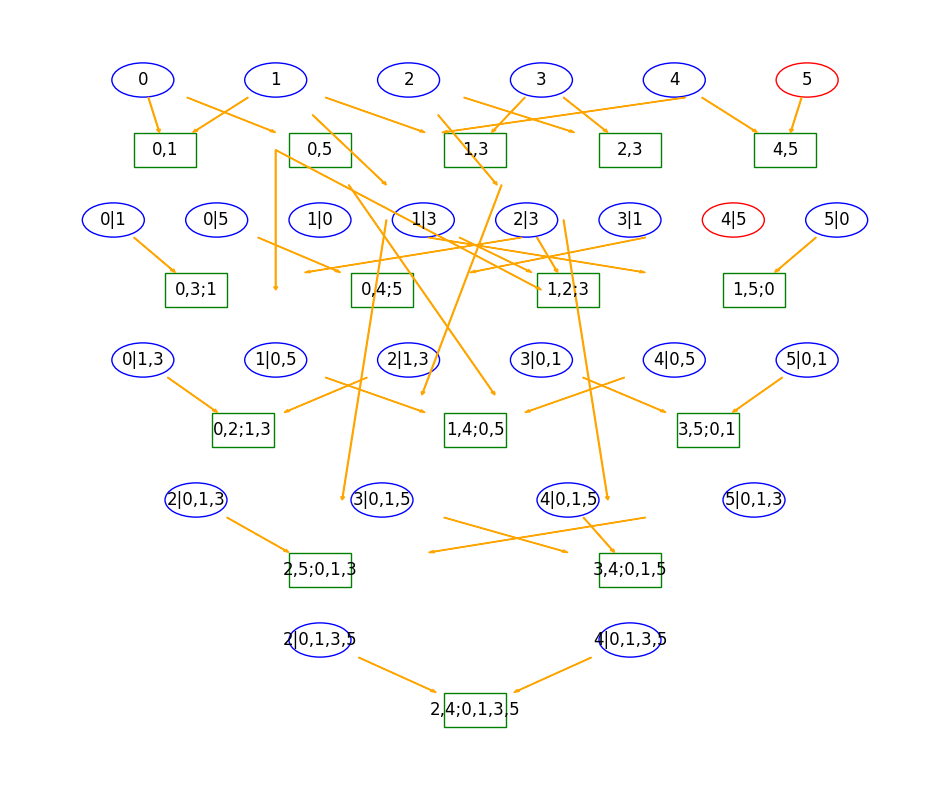

In [61]:
draw_graph(obs_list, tree_list, arrow_list, special_nodes, save_path=None)

现在的问题是生成箭头的列表混乱。要重新调整一下生成箭头列表的结构，并且要优化一下函同一层中元素顺序的排布。
另外diag函数生成的值和图中的点有些也对不上，要考虑一下是diag函数提取的问题还是上面的提取中导致了漏点。
prompt:
1.修改arrow_list的生成逻辑。其中，在每次        
for v_l, v_r, s_and in self.dct_tree[lv]:
的循环中，不再需要做有关arrow_list的生成代码，而是在这个循环结束后，根据生成并排好序的tree_list和obs_list生成arrow_list。
2.生成的逻辑如下：
遍历tree_list当中的每一个元素（也就是里面的每一个列表），从第0个列表开始，如果同层的obs列表中有obs分隔符前面的元素包含在tree分隔符前面两个元素之一，则要生成一个列表放在arrow_list中，其中列表中的第一个元素为obs中的元素，第二个元素为tree中的元素。
比如，第0层tree的某个点是（0，1），则你需要遍历第0层obs的所有点，如果有点（0）或点（1），则他们分隔符前面的元素被包含在点（0，1）中，则需要分别生成两个列表["0", "0,1"]和["1", "0,1"]在arrow_list中。以此法遍历第0层中tree的每一个字符串并如是处理，然后还要遍历所有层，所有结果都是加写在arrow_list列表中。
3.然后还是对于每一层的tree，做一个检定，如果还有下一层的obs，则还要以以下逻辑增添箭头：
对于某一层第i层的tree，还是遍历检索里面的每一个字符串，提取其中除了符号外的所有数字。然后遍历下一层第（i+1）层的obs的每一个字符串，也提取其中所有除了符号外的数字（都没有顺序，相当于把其中的每一个非符号的数字都当成一个元素，然后分别放在一个set中）。
然后检测，如果某个tree中点生成的set与下一层的某个obs中字符串生成的set中的元素完全相同，则需要生成一个列表，其中列表中的第一个元素为tree中的元素，第二个元素为下一层obs中的元素。
比如，第2层的某个点是"0,2;1,3",则你提取所有非符号的数字应该是set(0,1,2,3)。而下一层的obs有一个点是"2|0,1,3"，则提取所有非符号的数字set也是(0,1,2,3)。这两个set完全相同，则应该生成一个列表["0,2;1,3", "2|0,1,3"],加入arrow_list中。
以此法遍历每一层treez中的每一个元素，再遍历每一层的tree，直到某一层下面没有再下一层的obs了为止。
4. 第二步和第三步两种检索方法生成的所有含有两个字符串的列表，都要放到统一的列表arrow_list中。最终都遍历完后，要将大列表arrow_list去重然后排序，从而生成arrow_list。

In [ ]:
def process_tree(self):
    obs_list = []
    tree_list = []
    arrow_list = []
    special_nodes = []

    for lv in range(len(self.dct_tree)):
        obs_list.append(sorted([v for v, _, _ in self.dct_tree[lv]]))
        tree_list.append(sorted([f"{v_l},{v_r}" for v_l, v_r, _ in self.dct_tree[lv]]))

    # 生成arrow_list
    for lv in range(len(tree_list)):
        for tree in tree_list[lv]:
            tree_set = set([tree[0], tree[2]])  # 提取tree中字符串的第0位和第2位形成一个set
            for obs in obs_list[lv]:
                if obs[0] in tree_set:  # 提取obs中的字符串的首位，看它是否在set中
                    arrow_list.append([obs, tree])

        if lv < len(obs_list) - 1:
            for tree in tree_list[lv]:
                tree_set = set(tree.replace(";", ",").split(","))
                for obs in obs_list[lv + 1]:
                    obs_set = set(obs.replace("|", ",").split(","))
                    if tree_set == obs_set:
                        arrow_list.append([tree, obs])

    arrow_list = sorted(list(set(map(tuple, arrow_list))), key=lambda x: (x[0], x[1]))

    for v, _, _ in self.diag:
        special_nodes.append(v)

    return obs_list, tree_list, arrow_list, special_nodes

3.10更新：
更换了生成arrow_list的逻辑，保证箭头生成的正确性。
同时保证了每一层点的顺序是有序的，避免混乱。
process_tree以下面这个版本为准。draw_graph还是用上面的就可以，那个已经很完备了，不用改。

In [68]:
def process_tree(self):
    # 初始化列表
    lst_tree = [None] * len(self.dct_tree)
    lst_ob = [None] * len(self.dct_tree)
    tree_list = []
    obs_list = []
    arrow_list = []

    # 遍历每一层
    for lv in range(len(self.dct_tree)):
        lst_tree[lv] = []
        lst_ob[lv] = []
        # 遍历每一层的每一个元素
        for v_l, v_r, s_and in self.dct_tree[lv]:
            # 转换元素为字符串
            s_and_str = ','.join(str(item) for item in s_and) if s_and else ''
            lst_tree[lv].append(f"{v_l},{v_r}" + (f";{s_and_str}" if s_and_str else ''))
            # 记录观察点
            lst_ob[lv].append(f"{v_l}" + (f"|{s_and_str}" if s_and_str else ''))
            lst_ob[lv].append(f"{v_r}" + (f"|{s_and_str}" if s_and_str else ''))
        # 将每一层的列表打包进大列表
        tree_list.append(sorted(list(set(lst_tree[lv]))))  # 使用集合去重并排序
        obs_list.append(sorted(list(set(lst_ob[lv]))))  # 使用集合去重并排序
        
    # 生成arrow_list
    for lv in range(len(tree_list)):
        for tree in tree_list[lv]:
            tree_set = set([tree[0], tree[2]])  # 提取tree中字符串的第0位和第2位形成一个set
            tree_postfix = tree.split(";")[1] if ";" in tree else ""  # 提取tree分隔符";"后面的元素
            for obs in obs_list[lv]:
                obs_prefix = obs[0]  # 提取obs中的字符串的首位
                obs_postfix = obs.split("|")[1] if "|" in obs else ""  # 提取obs分隔符"|"后面的元素
                if obs_prefix in tree_set and obs_postfix == tree_postfix:  # 检查两个条件是否都满足
                    arrow_list.append([obs, tree])

        if lv < len(obs_list) - 1:
            for tree in tree_list[lv]:
                tree_set = set(tree.replace(";", ",").split(","))
                for obs in obs_list[lv + 1]:
                    obs_set = set(obs.replace("|", ",").split(","))
                    if tree_set == obs_set:
                        arrow_list.append([tree, obs])
    
    # 去重并排序，实际上可能并不需要这个操作
    arrow_list = sorted(list(set(map(tuple, arrow_list))), key=lambda x: (x[0], x[1]))

    # 生成special_nodes列表
    lst_diag = self.diag
    lst_diag = [(v, frozenset(lst_diag[(idx + 1) :])) for idx, v in enumerate(lst_diag)][::-1]
    special_nodes = [f"{v}" + (f"|{','.join(str(item) for item in s)}" if s else '') for v, s in lst_diag]
    # 返回四个列表
    return obs_list, tree_list, arrow_list, special_nodes

[['0', '1', '2', '3', '4', '5'], ['0|1', '0|5', '1|0', '1|3', '2|3', '3|1', '4|5', '5|0'], ['0|1,3', '1|0,5', '2|1,3', '3|0,1', '4|0,5', '5|0,1'], ['2|0,1,3', '3|0,1,5', '4|0,1,5', '5|0,1,3'], ['2|0,1,3,5', '4|0,1,3,5']]
[['0,1', '0,5', '1,3', '2,3', '4,5'], ['0,3;1', '0,4;5', '1,2;3', '1,5;0'], ['0,2;1,3', '1,4;0,5', '3,5;0,1'], ['2,5;0,1,3', '3,4;0,1,5'], ['2,4;0,1,3,5']]
[('0', '0,1'), ('0', '0,5'), ('0,1', '0|1'), ('0,1', '1|0'), ('0,2;1,3', '2|0,1,3'), ('0,3;1', '0|1,3'), ('0,3;1', '3|0,1'), ('0,4;5', '4|0,5'), ('0,5', '0|5'), ('0,5', '5|0'), ('0|1', '0,3;1'), ('0|1,3', '0,2;1,3'), ('0|5', '0,4;5'), ('1', '0,1'), ('1', '1,3'), ('1,2;3', '2|1,3'), ('1,3', '1|3'), ('1,3', '3|1'), ('1,4;0,5', '4|0,1,5'), ('1,5;0', '1|0,5'), ('1,5;0', '5|0,1'), ('1|0', '1,5;0'), ('1|0,5', '1,4;0,5'), ('1|3', '1,2;3'), ('2', '2,3'), ('2,3', '2|3'), ('2,5;0,1,3', '2|0,1,3,5'), ('2|0,1,3', '2,5;0,1,3'), ('2|0,1,3,5', '2,4;0,1,3,5'), ('2|1,3', '0,2;1,3'), ('2|3', '1,2;3'), ('3', '1,3'), ('3', '2,3'), ('3,

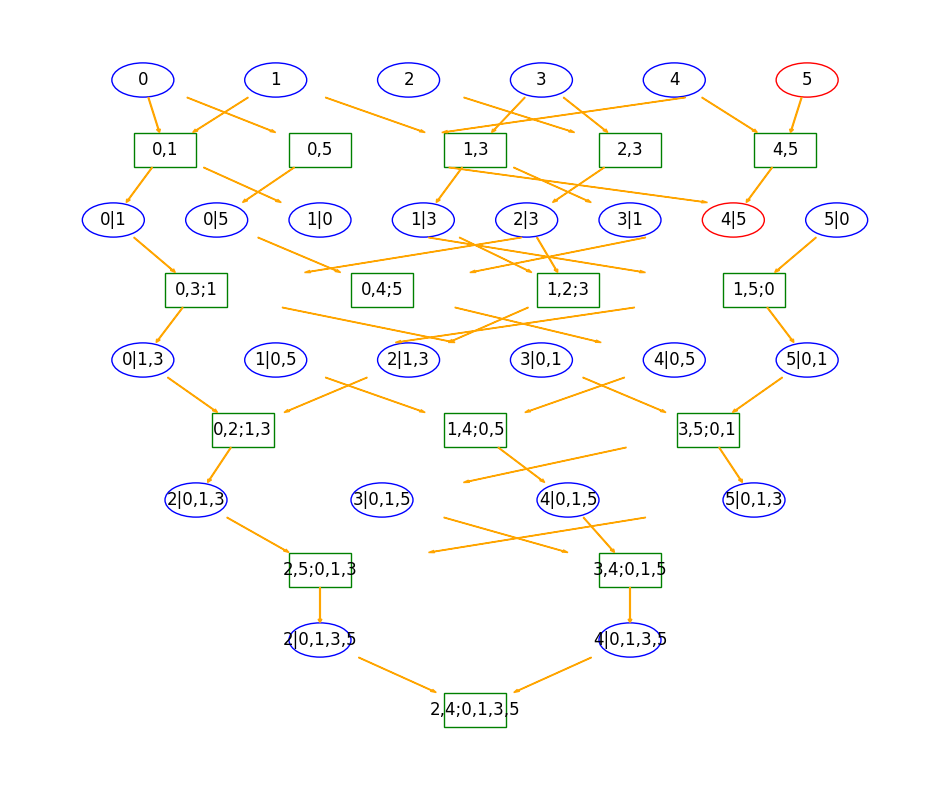

In [69]:
self = mdl_vcp
obs_list, tree_list, arrow_list, special_nodes = process_tree(self)
print(obs_list)
print(tree_list)
print(arrow_list)
print(special_nodes)
draw_graph(obs_list, tree_list, arrow_list, special_nodes, save_path=None)